In [2]:
import pandas as pd
import numpy as np
%pip install seaborn 
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv('wine_data.csv')
df.head()
# df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
# df

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [12]:
df=pd.read_csv('wine_data.csv',header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [14]:
df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.head()

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [15]:
df.columns=['Class Label','Alcohol','Malic Acid']
df.head()

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

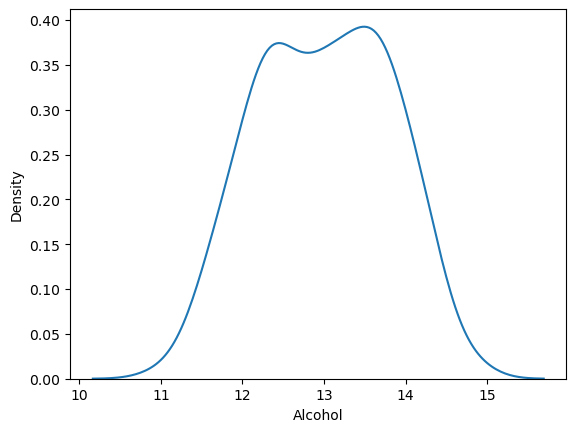

In [16]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

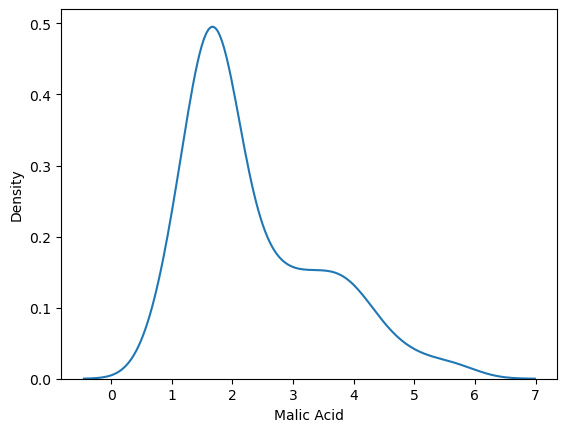

In [17]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

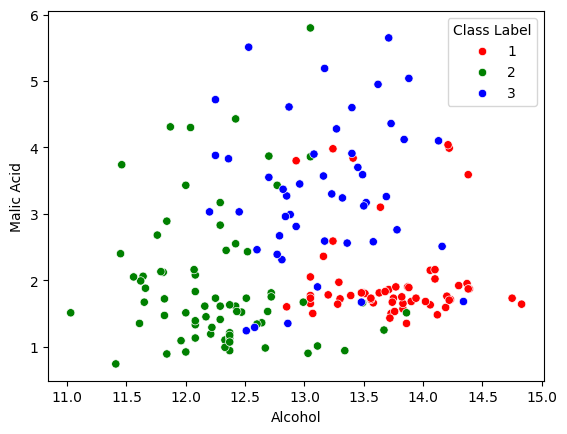

In [20]:
color_dict={1:'red',2:'green',3:'blue'}
sns.scatterplot(x=df['Alcohol'],y=df['Malic Acid'],hue=df['Class Label'],palette=color_dict)

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Class Label',axis=1),df['Class Label'],test_size=0.3,random_state=0)

In [25]:
X_train.shape,X_test.shape,y_train.shape

((124, 2), (54, 2), (124,))

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [28]:
scaler.fit(X_train)
# # fit the scaler to the train set, it will learn the parameters


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [29]:
# transform
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [33]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)
X_test_scaled.head()


,Alcohol,Malic Acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513


In [34]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


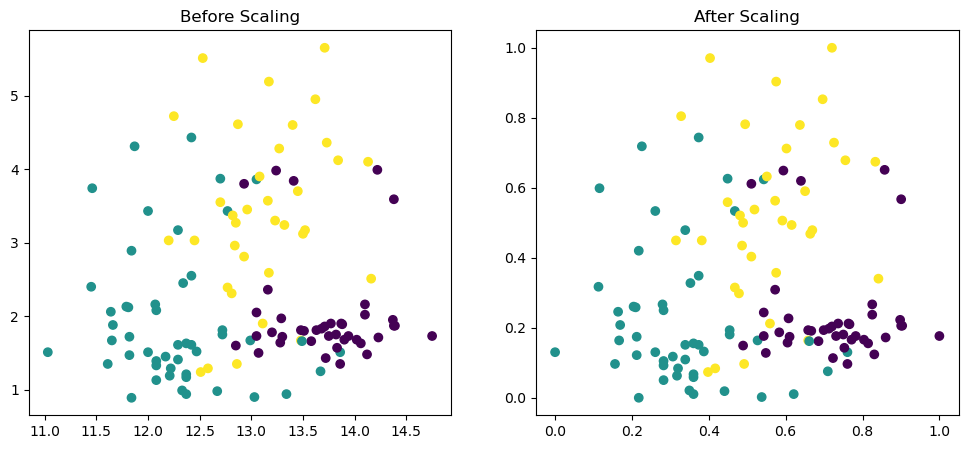

In [48]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
ax1.scatter(X_train['Alcohol'],X_train['Malic Acid'],c=y_train)

ax2.set_title('After Scaling')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic Acid'],c=y_train)
# ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)

plt.show()

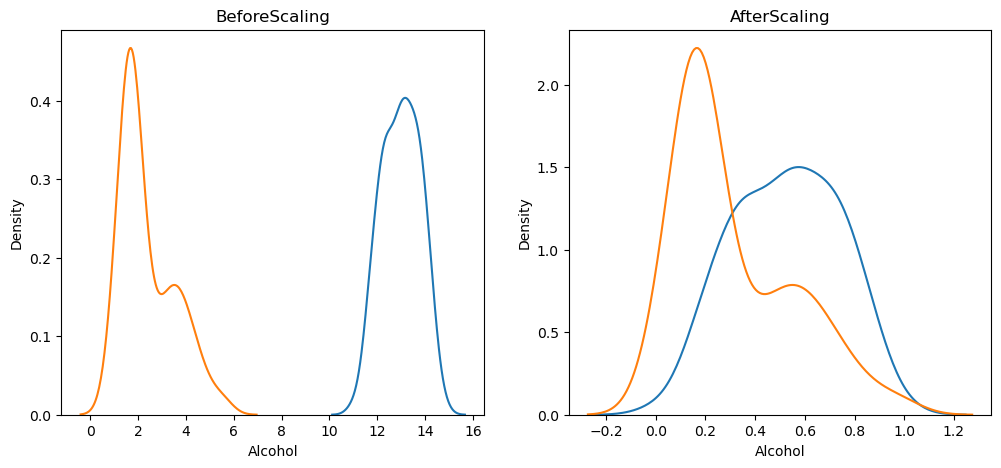

In [58]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('BeforeScaling')
sns.kdeplot(X_train['Alcohol'],ax=ax1)
sns.kdeplot(X_train['Malic Acid'],ax=ax1)

ax2.set_title('AfterScaling')
sns.kdeplot(X_train_scaled['Alcohol'],ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'],ax=ax2)
plt.show()

<Axes: title={'center': 'Alcohol dist after scaling'}, xlabel='Alcohol', ylabel='Density'>

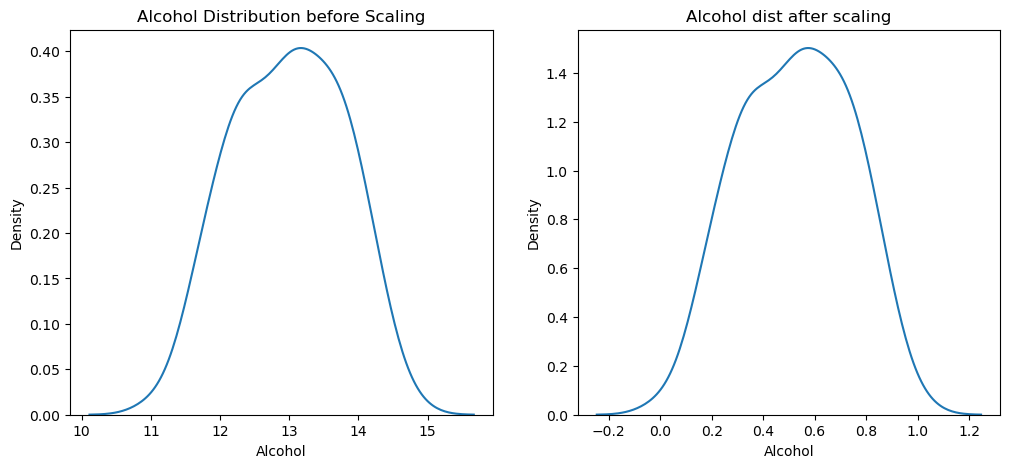

In [59]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Alcohol Distribution before Scaling')
sns.kdeplot(X_train['Alcohol'],ax=ax1)

ax2.set_title('Alcohol dist after std. scaling')
sns.kdeplot(X_train_scaled['Alcohol'],ax=ax2)
plt.show()